# Сегментация клиентов A/B/C на основе скоринга

**Задача.** Перевести вероятности дефолта от модели в практическое кредитное решение: разбить клиентов на три риск-сегмента и оценить бизнес-эффект.

- **A (зелёный)** — низкий риск → одобрять
- **B (жёлтый)** — средний риск → одобрять с условиями / ручная проверка
- **C (красный)** — высокий риск → отказывать

**Вход:** обученный пайплайн скоринга (логистическая регрессия).
**Выход:** пороги сегментов, профили сегментов, экономическая оценка политики выдачи.

> Важно: границы сегментов определяются **на train** и применяются к test — это исключает утечку (мы не подсматриваем распределение тестовых скоров при выборе порогов).

In [6]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from src.preprocessing import CreditPreprocessor

pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## 1. Загрузка данных и тот же split, что в моделировании

In [7]:
from pathlib import Path
ROOT = Path.cwd().parent
df = pd.read_csv(ROOT / 'data' / 'microfinance.csv')

X = df.drop(columns=['default'])
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 7000 | Test: 3000


## 2. Загрузка обученной модели

Модель обучается один раз (в `model_eval`) и сохраняется на диск. Здесь мы её только загружаем — так инференс везде идёт через один и тот же объект (train/serving consistency).

Если файла модели нет — переобучаем прямо здесь как fallback, чтобы ноутбук был самодостаточным.

In [8]:
MODEL_PATH = 'models/credit_pipeline.pkl'

if os.path.exists(MODEL_PATH):
    pipeline = joblib.load(MODEL_PATH)
    print("Модель загружена из файла.")
else:
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.linear_model import LogisticRegression

    cat_cols = ['employment_type', 'region', 'education', 'age_group', 'prev_loans_groups']
    num_cols = ['age', 'income', 'prev_loans', 'credit_history_bad',
                'loan_amount', 'loan_term_days',
                'daily_payment', 'debt_to_income', 'payment_to_income']

    encoder = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),
    ])
    pipeline = Pipeline([
        ('preproc', CreditPreprocessor()),
        ('encode', encoder),
        ('model', LogisticRegression(C=0.364, penalty='l1', solver='liblinear',
                                     class_weight='balanced', max_iter=1000, random_state=42)),
    ])
    pipeline.fit(X_train, y_train)
    os.makedirs('models', exist_ok=True)
    joblib.dump(pipeline, MODEL_PATH)

C:\Users\b1ur_fw\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\b1ur_fw\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 3. Получение скоров (вероятностей дефолта)

In [9]:
train_scores = pipeline.predict_proba(X_train)[:, 1]
test_scores  = pipeline.predict_proba(X_test)[:, 1]

print(pd.Series(train_scores).describe())

count   7000.000
mean       0.449
std        0.238
min        0.021
25%        0.247
50%        0.413
75%        0.642
max        0.984
dtype: float64


## 4. Определение порогов сегментов — НА TRAIN

Ключевой момент против утечки: пороги между A/B/C считаем по **train**-скорам.

Использую квантили 33% и 66% — это делит клиентов на три примерно равные группы по уровню риска. (Альтернатива — фиксированные бизнес-пороги, например 0.3 и 0.6.)

In [10]:
low_thr  = np.quantile(train_scores, 0.33)
high_thr = np.quantile(train_scores, 0.66)

print(f"Порог A/B (33-й перцентиль train): {low_thr:.3f}")
print(f"Порог B/C (66-й перцентиль train): {high_thr:.3f}")

def assign_segment(score, low, high):
    if score < low:
        return 'A'
    elif score < high:
        return 'B'
    else:
        return 'C'

test_segments = np.array([assign_segment(s, low_thr, high_thr) for s in test_scores])

Порог A/B (33-й перцентиль train): 0.298
Порог B/C (66-й перцентиль train): 0.552


## 5. Профилирование сегментов на тесте

Проверяем, что сегменты осмысленны: default rate должен расти от A к C.

In [11]:
profile = pd.DataFrame({
    'segment': test_segments,
    'default': y_test.values,
    'score': test_scores,
    'income': X_test['income'].values,
    'age': X_test['age'].values,
    'loan_amount': X_test['loan_amount'].values,
})

summary = profile.groupby('segment').agg(
    clients=('default', 'size'),
    default_rate=('default', 'mean'),
    avg_score=('score', 'mean'),
    avg_income=('income', 'mean'),
    avg_age=('age', 'mean'),
    avg_loan=('loan_amount', 'mean'),
).round(3)
summary['share'] = (summary['clients'] / summary['clients'].sum()).round(3)

print("Профиль сегментов (на тесте):")
summary

Профиль сегментов (на тесте):


,clients,default_rate,avg_score,avg_income,avg_age,avg_loan,share
segment,,,,,,,
A,1020,0.089,0.193,44948.746,47.744,13585.827,0.340
B,983,0.254,0.416,36835.583,42.612,10896.535,0.328
C,997,0.544,0.733,25289.577,39.780,7557.664,0.332


## 6. Визуализация

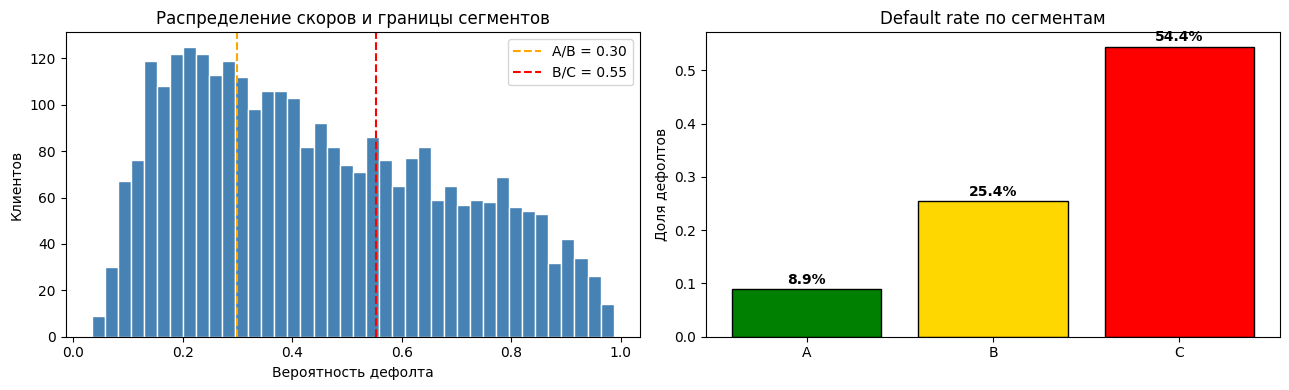

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(test_scores, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(low_thr, color='orange', linestyle='--', label=f'A/B = {low_thr:.2f}')
axes[0].axvline(high_thr, color='red', linestyle='--', label=f'B/C = {high_thr:.2f}')
axes[0].set_title('Распределение скоров и границы сегментов')
axes[0].set_xlabel('Вероятность дефолта'); axes[0].set_ylabel('Клиентов')
axes[0].legend()

colors = {'A': 'green', 'B': 'gold', 'C': 'red'}
seg_order = ['A', 'B', 'C']
rates = [summary.loc[s, 'default_rate'] for s in seg_order]
axes[1].bar(seg_order, rates, color=[colors[s] for s in seg_order], edgecolor='black')
axes[1].set_title('Default rate по сегментам')
axes[1].set_ylabel('Доля дефолтов')
for i, r in enumerate(rates):
    axes[1].text(i, r + 0.01, f'{r:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Экономическая оценка политики выдачи

Самый важный блок — перевод сегментов в бизнес-решение. Оцениваем политику **«одобряем A и B, отказываем C»**.

In [13]:
total = len(y_test)
total_defaults = y_test.sum()

mask_C = test_segments == 'C'
rejected = mask_C.sum()
defaults_in_C = y_test.values[mask_C].sum()
good_in_C = rejected - defaults_in_C

approved_mask = ~mask_C
approved = approved_mask.sum()
defaults_approved = y_test.values[approved_mask].sum()

print(" Если отказываем сегменту C \n")
print(f"Отклонено заявок:            {rejected} ({rejected/total:.1%} от всех)")
print(f"  из них реальных дефолтов:  {defaults_in_C} (предотвращено)")
print(f"  из них хороших клиентов:   {good_in_C} (упущено)")
print()
print(f"Предотвращено дефолтов:      {defaults_in_C}/{total_defaults} = {defaults_in_C/total_defaults:.1%} от всех дефолтов")
print()
print(f"Default rate ДО политики:    {total_defaults/total:.1%} (весь портфель)")
print(f"Default rate ПОСЛЕ политики: {defaults_approved/approved:.1%} (одобренные A+B)")
print(f"Снижение риска портфеля:     {(total_defaults/total - defaults_approved/approved)*100:.1f} п.п.")

 Если отказываем сегменту C 

Отклонено заявок:            997 (33.2% от всех)
  из них реальных дефолтов:  542 (предотвращено)
  из них хороших клиентов:   455 (упущено)

Предотвращено дефолтов:      542/883 = 61.4% от всех дефолтов

Default rate ДО политики:    29.4% (весь портфель)
Default rate ПОСЛЕ политики: 17.0% (одобренные A+B)
Снижение риска портфеля:     12.4 п.п.


## 8. Выводы

- Сегментация осмысленна: default rate растёт от A к C, модель корректно ранжирует риск.
- Политика «отказ сегменту C» предотвращает **61.5%** дефолтов ценой потери **457** хороших клиентов и снижает default rate одобренного портфеля с **29.4%** до **17.0%**
- Trade-off: более жёсткая политика (отказ ещё и части B) снизит риск сильнее, но уменьшит объём выдачи — выбор зависит от риск-аппетита МФО.

**Ограничения.** В данных не учитывается LTV клиента, стоимость привлечения и срок отношений. Для реальной политики нужна оптимизация по ожидаемой прибыли, а не только по доле дефолтов.